Dataset Load Karo

In [53]:
import pandas as pd
df = pd.read_csv("C:\\Users\\LENOVO\\OneDrive\\Desktop\\claimguard\\data\\fraud_oracle.csv")
print(df.shape)

(15420, 33)


Columns Aur Types Dekho

In [54]:
print(df.columns.tolist())
print(df.dtypes)

['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']
Month                     str
WeekOfMonth             int64
DayOfWeek                 str
Make                      str
AccidentArea              str
DayOfWeekClaimed          str
MonthClaimed              str
WeekOfMonthClaimed      int64
Sex                       str
MaritalStatus             str
Age                     int64
Fault                     str
PolicyType                str
VehicleCategory           str
VehiclePrice              str
FraudFound_P            in

Missing Values Check

In [55]:
print(df.isnull().sum())

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64


Age Sanity Check

In [56]:
print(df[df['Age'] < 0])
print(df[df['Age'] > 100])

Empty DataFrame
Columns: [Month, WeekOfMonth, DayOfWeek, Make, AccidentArea, DayOfWeekClaimed, MonthClaimed, WeekOfMonthClaimed, Sex, MaritalStatus, Age, Fault, PolicyType, VehicleCategory, VehiclePrice, FraudFound_P, PolicyNumber, RepNumber, Deductible, DriverRating, Days_Policy_Accident, Days_Policy_Claim, PastNumberOfClaims, AgeOfVehicle, AgeOfPolicyHolder, PoliceReportFiled, WitnessPresent, AgentType, NumberOfSuppliments, AddressChange_Claim, NumberOfCars, Year, BasePolicy]
Index: []

[0 rows x 33 columns]
Empty DataFrame
Columns: [Month, WeekOfMonth, DayOfWeek, Make, AccidentArea, DayOfWeekClaimed, MonthClaimed, WeekOfMonthClaimed, Sex, MaritalStatus, Age, Fault, PolicyType, VehicleCategory, VehiclePrice, FraudFound_P, PolicyNumber, RepNumber, Deductible, DriverRating, Days_Policy_Accident, Days_Policy_Claim, PastNumberOfClaims, AgeOfVehicle, AgeOfPolicyHolder, PoliceReportFiled, WitnessPresent, AgentType, NumberOfSuppliments, AddressChange_Claim, NumberOfCars, Year, BasePolicy]
I

Fraud Vs Genuine Ratio

In [57]:
print(df['FraudFound_P'].value_counts())

FraudFound_P
0    14497
1      923
Name: count, dtype: int64


PolicyNumber Duplicate Check

In [58]:
print(df['PolicyNumber'].value_counts().head())

PolicyNumber
1    1
2    1
3    1
4    1
5    1
Name: count, dtype: int64


EDA: Fault Vs Fraud

In [59]:
print(df.groupby('Fault')['FraudFound_P'].mean())

Fault
Policy Holder    0.078896
Third Party      0.008831
Name: FraudFound_P, dtype: float64


EDA: Police Report Vs Fraud

In [60]:
print(df.groupby('PoliceReportFiled')['FraudFound_P'].mean())

PoliceReportFiled
No     0.060499
Yes    0.037383
Name: FraudFound_P, dtype: float64


EDA: Witness Vs Fraud

In [61]:
print(df.groupby('WitnessPresent')['FraudFound_P'].mean())

WitnessPresent
No     0.060001
Yes    0.034483
Name: FraudFound_P, dtype: float64


EDA: Past Claims Vs Fraud

In [62]:
print(df.groupby('PastNumberOfClaims')['FraudFound_P'].mean())

PastNumberOfClaims
1              0.062133
2 to 4         0.053601
more than 4    0.033831
none           0.077895
Name: FraudFound_P, dtype: float64


EDA: Vehicle Category Vs Fraud

In [63]:
print(df.groupby('VehicleCategory')['FraudFound_P'].mean())

VehicleCategory
Sedan      0.082205
Sport      0.015677
Utility    0.112532
Name: FraudFound_P, dtype: float64


Graph Banao

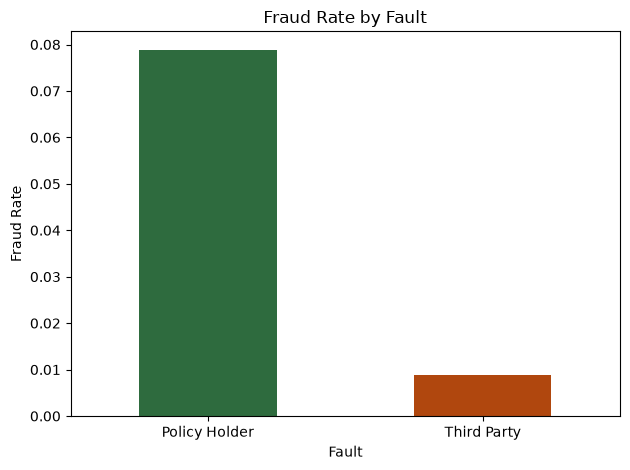

In [64]:
import matplotlib.pyplot as plt

df.groupby('Fault')['FraudFound_P'].mean().plot(kind='bar', color=['#2E6B3E', '#B0470E'])
plt.title('Fraud Rate by Fault')
plt.ylabel('Fraud Rate')
plt.xlabel('Fault')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fault_vs_fraud.png')
plt.show()

## EDA Findings — ClaimGuard

### 1. Fraud vs Genuine Ratio
- Genuine claims: 14,497 (94%)
- Fraud claims: 923 (6%)
- → There's a class imbalance, so I'll use precision/recall instead of accuracy

### 2. Fault vs Fraud
- Fraud rate when Policy Holder was at fault: 7.9%
- Fraud rate when Third Party was at fault: 0.9%
- → Fraud is almost 9x higher when the Policy Holder was at fault, compared to Third Party fault

### 3. Police Report Filed vs Fraud
- Fraud rate when NO police report was filed: 6.0%
- Fraud rate when a police report WAS filed: 3.7%
- → Not filing a police report is a real risk signal — fraud rate is about 1.6x higher

### 4. Witness Present vs Fraud
- Fraud rate when NO witness was present: 6.0%
- Fraud rate when a witness WAS present: 3.4%
- → No witness present is also a risk signal — fraud rate is about 1.7x higher

### 5. Past Number of Claims vs Fraud
- "None" (first-time claimant): 7.8%
- "1" past claim: 6.2%
- "2 to 4" past claims: 5.4%
- "More than 4" past claims: 3.4%
- → Interesting pattern: fraud rate is actually HIGHEST for first-time claimants, not repeat claimants — this is worth mentioning as a surprising finding

### 6. Vehicle Category vs Fraud
- Sedan: 8.2%
- Sport: 1.6%
- Utility: 11.3%
- → Utility vehicles have the highest fraud rate, Sport vehicles the lowest

"Here's an interesting finding — I expected that people with more past claims would look more suspicious, but the data showed the opposite. First-time claimants actually had the highest fraud rate. This counter-intuitive pattern shows me how important it is to check the data before making assumptions."

### ML Baseline (Step by Step)

In [65]:
import pandas as pd
print(df.shape)

(15420, 33)


In [66]:
X = df.drop(columns=['PolicyNumber', 'RepNumber', 'FraudFound_P'])
y = df['FraudFound_P']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (15420, 30)
Target shape: (15420,)


In [67]:
X_encoded = pd.get_dummies(X, drop_first=True)
print("Encoded shape:", X_encoded.shape)

Encoded shape: (15420, 122)


In [68]:
from sklearn.model_selection 
import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

SyntaxError: invalid syntax (35904418.py, line 1)